**Decision Tree**

Imagine a Decision Tree as a flowchart or a game of "20 Questions." It makes decisions by asking a series of questions about your data, leading you to a conclusion.
Easy to understand, little data prep needed, but its prone to overfitting. small change in data can lead to different tree structure entirely. so its prone to bias.

**Random Forest**

Now, imagine taking a "forest" of many individual Decision Trees and having them all work together. That's a Random Forest! It's an ensemble method, meaning it combines multiple models to get a better, more robust result.
bagging is used for selecting dataset - each tree may have different set of data.

For Classification: When making a prediction, all the trees in the forest "vote" on the outcome, and the class with the most votes wins.

For Regression: The predictions from all individual trees are averaged to get the final prediction.


A Decision Tree is a single flowchart. A Random Forest is a powerful "committee" of many independently built Decision Trees whose combined decisions are more accurate and reliable than any single tree could be.

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [114]:
df = pd.read_csv('../sample_data/shows.csv')
df.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          13 non-null     int64 
 1   Experience   13 non-null     int64 
 2   Rank         13 non-null     int64 
 3   Nationality  13 non-null     object
 4   Go           13 non-null     object
dtypes: int64(3), object(2)
memory usage: 648.0+ bytes


In [116]:
d = {'UK':0,'USA':0,'N':2}
df['Nationality'] =  df['Nationality'].map(d)
d1 = {'YES':1,'NO':0}
df['Go'] = df['Go'].map(d1)
df.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,0,0
1,42,12,4,0,0
2,23,4,6,2,0
3,52,4,4,0,0
4,43,21,8,0,1


In [117]:
df.columns

Index(['Age', 'Experience', 'Rank', 'Nationality', 'Go'], dtype='object')

In [118]:
features = ['Age', 'Experience', 'Rank', 'Nationality']
x = df[features]
y = df['Go']

In [119]:
dtree = DecisionTreeClassifier()
dtree.fit(x,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.3333333333333333, 0.875, 'Rank <= 6.5\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'Experience <= 9.5\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.375, 'Experience <= 11.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

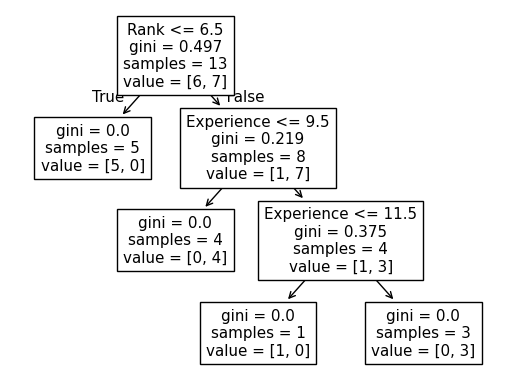

In [120]:
tree.plot_tree(dtree,feature_names = features)

In [121]:
print(df.to_string())

    Age  Experience  Rank  Nationality  Go
0    36          10     9            0   0
1    42          12     4            0   0
2    23           4     6            2   0
3    52           4     4            0   0
4    43          21     8            0   1
5    44          14     5            0   0
6    66           3     7            2   1
7    35          14     9            0   1
8    52          13     7            2   1
9    35           5     9            2   1
10   24           3     5            0   0
11   18           3     7            0   1
12   45           9     9            0   1


In [122]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y,dtree.predict(x)))
print(confusion_matrix(y,dtree.predict(x)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

[[6 0]
 [0 7]]


In [123]:
print(dtree.predict([[40,10,9,1]]))

[0]


c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Gini Impurity**  is a measure of how "pure" or "mixed" a node is in a decision tree.

A Gini Impurity of 0 signifies a perfectly pure node.0.5 means maximum impurity (where number of 'yes' is equal to 'no').

In [124]:
#another way to do this using pipeline and transformers
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

['Age', 'Experience', 'Rank', 'Nationality']
[]


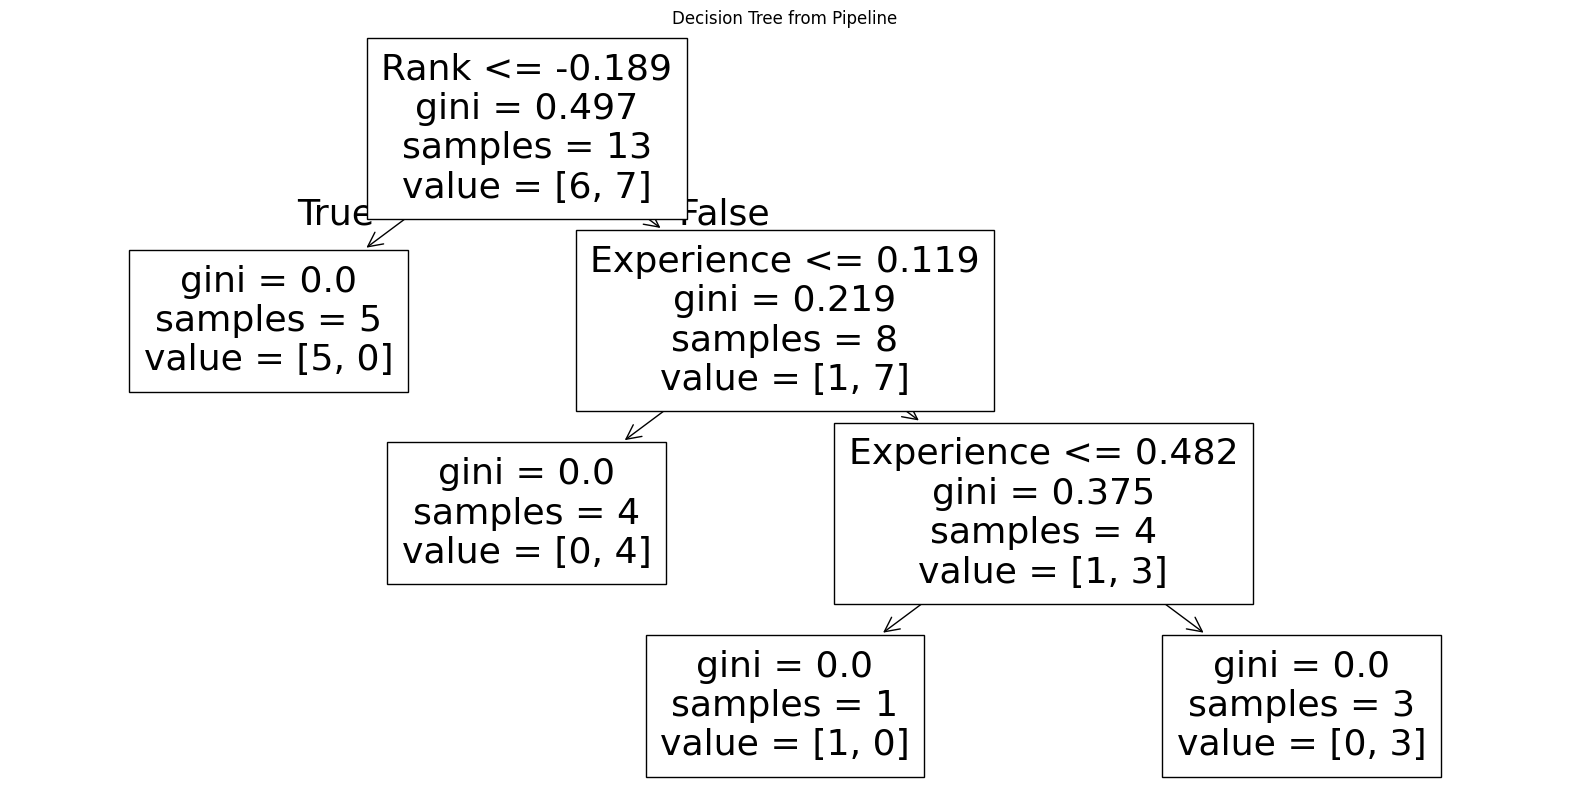

In [125]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

x = df.drop('Go',axis = 1)
y = df['Go']

features = [x.columns]
numerical_cols = [col for col in x.columns if x[col].dtype in ['int64','float64']]
categorical_cols = [col for col in x.columns if x[col].dtype == 'object']
print(numerical_cols)
print(categorical_cols)
numerical_transformer = StandardScaler()
categorical_transformer = Pipeline(steps = [('imputer',SimpleImputer(strategy = 'most_frequent')),('onehot',OneHotEncoder(handle_unknown = 'ignore'))])
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,numerical_cols),('cat',categorical_transformer,categorical_cols)]) #bundle it together

model = DecisionTreeClassifier()
mypipeline = Pipeline(steps = [('preprocessor',preprocessor),('model',model)])
dtree = mypipeline.fit(x,y)
fitted_tree_model = mypipeline.named_steps['model']
all_features_after_preprocessing = numerical_cols + categorical_cols
plt.figure(figsize=(20, 10)) # Adjust figure size as needed
plot_tree(
    fitted_tree_model,
    feature_names=all_features_after_preprocessing, # Use the correctly ordered feature names
    
)
plt.title("Decision Tree from Pipeline")
plt.show()

**Random forests**

In [126]:
df = pd.read_csv('../sample_data/kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [127]:
df.shape

(81, 4)

In [128]:
df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [130]:
df.columns

Index(['Kyphosis', 'Age', 'Number', 'Start'], dtype='object')

In [131]:
x = df.drop('Kyphosis',axis = 1)
y = df['Kyphosis']

In [132]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 0)

In [133]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [134]:
pred_tree = dtree.predict(x_test)

In [135]:
print(confusion_matrix(y_test,pred_tree))
print(classification_report(y_test,pred_tree))

[[16  2]
 [ 6  1]]
              precision    recall  f1-score   support

      absent       0.73      0.89      0.80        18
     present       0.33      0.14      0.20         7

    accuracy                           0.68        25
   macro avg       0.53      0.52      0.50        25
weighted avg       0.62      0.68      0.63        25



In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
rf = RandomForestClassifier(n_estimators = 100)
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)

In [137]:
print(confusion_matrix(y_test,rf_pred))
print(classification_report(y_test,rf_pred))
print(mean_absolute_error(y_test,rf_pred))

[[17  1]
 [ 6  1]]
              precision    recall  f1-score   support

      absent       0.74      0.94      0.83        18
     present       0.50      0.14      0.22         7

    accuracy                           0.72        25
   macro avg       0.62      0.54      0.53        25
weighted avg       0.67      0.72      0.66        25



ValueError: could not convert string to float: 'present'

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

x = df.drop('Kyphosis',axis = 1)
y = df.Kyphosis

numerical_cols = [col for col in x.columns if x[col].dtype in ['int64','float64']]
categorical_cols = [col for col in x.columns if x[col].dtype == 'object']
print(numerical_cols)
print(categorical_cols)

numerical_transformer = StandardScaler()
le = LabelEncoder()
y = le.fit_transform(df['Kyphosis'])
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,numerical_cols)])
model = RandomForestClassifier(n_estimators = 100)
mypipeline = Pipeline(steps = [('preprocessor',preprocessor),('model',model)])

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 0)
mypipeline.fit(x_train,y_train)
y_pred = mypipeline.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))


['Age', 'Number', 'Start']
[]
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        12
           1       0.33      0.20      0.25         5

    accuracy                           0.65        17
   macro avg       0.52      0.52      0.51        17
weighted avg       0.60      0.65      0.62        17

[[10  2]
 [ 4  1]]
0.35294117647058826
